In [1]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import skactiveml
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, ElementFraction
from matminer.featurizers.base import MultipleFeaturizer
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
# plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Config
CSV_PATH = '../data/bg_id/bg_id.csv'
TARGET_COL = ''

BLACKLIST_COLS = ['bg_hse06 (eV)','bg_pbesol (eV)','formula','material','composition']
Magpie_features = ElementProperty.from_preset('magpie').feature_labels()
innate_features = [
    'material',
    'formula',
    'bg_hse06 (eV)',
    'bg_pbesol (eV)',
    'r_s (AA)',
    'r_val (AA)',
    'e_H (eV)',
    'e_L (eV)',
    'AN',
    'IP (eV)',
    'EA (eV)',
    'r_cov (AA)',
    'EN (Pauling)',
    'N_val',
    'N_unf',
    'CE (eV/atom)',
]
features_full = innate_features + Magpie_features
features = [c for c in features_full if c not in BLACKLIST_COLS]

def build_X(df, scaler=StandardScaler(), train=False, raw=False):
    '''
    Build X with scaled continuous part and fingerprints.

    Args:
        df: dataframe with a 'smiles' column and qm9_features columns
        scaler: fitted scaler, or None to create a StandardScaler
        train: if True, fit scaler on continuous features
        raw: if True, return unscaled X
        n_jobs: number of CPU cores to use for fingerprinting

    Returns:
        X: feature matrix
    '''
    df = df.copy()
    X = df[features].to_numpy()

    if raw:
        return X

    X = (
        scaler.fit_transform(X) if train
        else scaler.transform(X)
    )

    return X

def plot_prediction(X, y, model, model_name=None, name=TARGET_COL, figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predictions for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        model_name: Name of the model (str).
        name: Name of the target value (str).
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    y_pred = model.predict(X)
    errors = np.abs(y - y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y, y_pred, c=errors, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    if model_name is None:
        ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    else:
        ax.set_title(f'{name} {model_name} prediction plot')
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mean_absolute_error(y,y_pred):.4f}')
    print(f'MSE = {mean_squared_error(y,y_pred):.4f}')
    print(f'RMSE = {root_mean_squared_error(y,y_pred):.4f}')
    print(f'r^2 = {r2_score(y,y_pred):.4f}')

def print_cross_val(X, y, model, splits=5, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        n_splits: Number of CV splits (int).
        random_state: Random state seed (int).
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae':  'neg_mean_absolute_error',
        'mse':  'neg_mean_sqared_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)

    print('Cross-validation scores:')
    print(f'Mean MAE  = {np.mean(np.abs(results['test_mae'])):.4f}')
    print(f'Mean MSE  = {np.mean(np.abs(results['test_mse'])):.4f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.4f}')
    print(f'Mean R²   = {np.mean(results['test_r2']):.4f}')

def plot_violin(X, y, models, metric='rmse', target_name=TARGET_COL, splits=5, y_min=0, y_max=None, figsize=(10, 6)):
    '''
    Plot RMSE violin plot for given models and data.

    Args:
        X           : Input features (np.array).
        y           : True target values (np.array).
        models      : List of unfitted model instances (list).
        target_name : Label for plot title (str).
        splits      : Number of CV splits (int).
        y_min       : Y-axis min value (float).
        y_max       : Y-axis max value (float).
        metric      : 'rsr' or 'rmse' (str)
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    records = []
    for model in models:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        if metric == 'rmse':
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RMSE': -score})
        else:
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
                
    df_plot = pd.dataFrame(records)

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df_plot,
        y='RMSE' if metric == 'rmse' else 'RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{target_name}\nModel Comparison — CV RMSE Scores' if metric == 'rmse' else f'{target_name}\nModel Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

#### Import dataset `bg_id.csv`
Target variables
- **bg_hse06:** Band gap calculated with HSE06 hybrid functional
- **bg_pbesol:** Band gap calculated with PBEsol GGA functional

Features
- **r_s:** Wigner-Seitz radius?
- **r_val:** Valence radius
- **r_cov:** Covalent radius
- **e_H:** HOMO Energy
- **e_L:** LUMO Energy
- **AN:** Atomic number
- **IP:** Ionisation potential
- **EA:** Electron affinity
- **EN:** Electronegativity
- **N_val:** Valence electrons
- **N_unf:** Unfilled electrons
- **CE:** Cohesive energy per atom

In [43]:
# Stratified split (bg_hse06)
df = pd.read_csv(CSV_PATH)

# Parse formula to Composition
df['composition'] = df['formula'].apply(Composition)

# Define element featurizers
featurizer = ElementProperty.from_preset('magpie')

# Featurize
featurizer.set_n_jobs(1)
df = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(df['bg_hse06 (eV)'], q=20, labels=False)
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(df_temp['bg_hse06 (eV)'], q=20, labels=False)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
df_train.to_csv('../data/bg_id/hse06/bg_id_hse06_train.csv', index=False)
df_test.to_csv('../data/bg_id/hse06/bg_id_hse06_test.csv', index=False)
df_val.to_csv('../data/bg_id/hse06/bg_id_hse06_val.csv', index=False)

ElementProperty:   0%|          | 0/950 [00:00<?, ?it/s]

In [44]:
# Stratified split (bg_pbesol)
df = pd.read_csv(CSV_PATH)

# Parse formula to Composition
df['composition'] = df['formula'].apply(Composition)

# Define element featurizers
featurizer = ElementProperty.from_preset('magpie')

# Featurize
featurizer.set_n_jobs(1)
df = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(df['bg_pbesol (eV)'], q=20, labels=False)
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(df_temp['bg_pbesol (eV)'], q=20, labels=False)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
df_train.to_csv('../data/bg_id/pbesol/bg_id_pbesol_train.csv', index=False)
df_test.to_csv('../data/bg_id/pbesol/bg_id_pbesol_test.csv', index=False)
df_val.to_csv('../data/bg_id/pbesol/bg_id_pbesol_val.csv', index=False)

ElementProperty:   0%|          | 0/950 [00:00<?, ?it/s]

In [2]:
TARGET_COL = 'bg_hse06 (eV)'
# Load
df_train = pd.read_csv('../data/bg_id/hse06/bg_id_hse06_train.csv')
df_test = pd.read_csv('../data/bg_id/hse06/bg_id_hse06_test.csv')
df_val = pd.read_csv('../data/bg_id/hse06/bg_id_hse06_val.csv')

X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
# X_cv = build_X(df_train, raw=True)
# X = build_X(df, raw=True)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
# y = df[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
# print(f'Full set Molecules: {X.shape[0]}  |  Features: {X.shape[1]}')

Train set Molecules: 760  |  Features: 144
Test set Molecules: 95  |  Features: 144
Validate set Molecules: 95  |  Features: 144


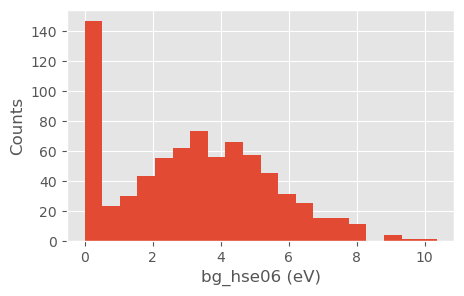

In [46]:
# Plot train histogram
plt.figure(figsize=(5,3))
plt.hist(df_train[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

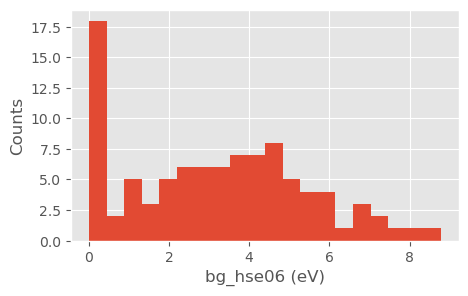

In [47]:
# Plot test histogram
plt.figure(figsize=(5,3))
plt.hist(df_test[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

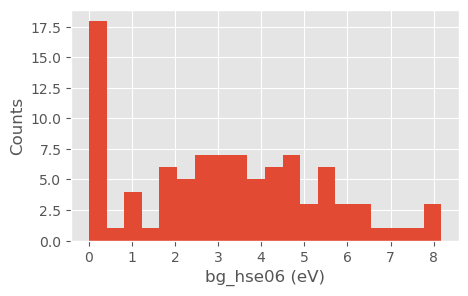

In [48]:
# Plot val histogram
plt.figure(figsize=(5,3))
plt.hist(df_val[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

## Baseline

### Train models

In [49]:
from sklearn.model_selection import GridSearchCV
# Grid search CV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8],
}

rf = RandomForestRegressor(random_state=42)

search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best params: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV r²: 0.734


In [57]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train,y_train)
joblib.dump(rf, 'models/rf/bg_id/rf_hse06_bg_id.pkl')

['models/rf/bg_id/rf_hse06_bg_id.pkl']

In [27]:
from sklearn.model_selection import GridSearchCV
# Grid search CV
param_grid = {
    'kernel': ['laplacian'],
    'gamma': [0.0001, 0.001, 0.01],
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],  # push alpha higher
}

search = GridSearchCV(
    KernelRidge(),
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Best params: {'alpha': 0.1, 'gamma': 0.01, 'kernel': 'laplacian'}
Best CV r²: 0.776


In [58]:
from sklearn.kernel_ridge import KernelRidge
kr = KernelRidge(
    alpha=0.1,
    gamma=0.01,
    kernel='laplacian',
)
kr.fit(X_train,y_train)
joblib.dump(kr, 'models/kr/bg_id/kr_hse06_bg_id.pkl')

['models/kr/bg_id/kr_hse06_bg_id.pkl']

In [29]:
from sklearn.model_selection import GridSearchCV
# Grid search CV
param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'min_child_weight': [3, 5, 10],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.1, 1.0, 5.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

search = GridSearchCV(
    XGBRegressor(booster='gbtree'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)
print(search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
{'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV r²: 0.789


In [59]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    n_estimators=500,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
)
xgb.fit(X_train,y_train)
joblib.dump(xgb, 'models/xgb/bg_id/xgb_hse06_bg_id.pkl')

['models/xgb/bg_id/xgb_hse06_bg_id.pkl']

In [60]:
from sklearn.ensemble import VotingRegressor
com = VotingRegressor(
    estimators=[
        ('rf', clone(rf)),
        ('xgb', clone(xgb)),
        ('kr', clone(kr)),
    ],
    n_jobs=-1,
)
com.fit(X_train,y_train)
joblib.dump(com, 'models/com/bg_id/com_hse06_bg_id.pkl')

['models/com/bg_id/com_hse06_bg_id.pkl']

### Load models

In [4]:
rf = joblib.load('models/rf/bg_id/rf_hse06_bg_id.pkl') #RandomForestRegressor
kr = joblib.load('models/kr/bg_id/kr_hse06_bg_id.pkl') #KernelRidge
xgb= joblib.load('models/xgb/bg_id/xgb_hse06_bg_id.pkl') #XGBRegressor
com= joblib.load('models/com/bg_id/com_hse06_bg_id.pkl') #Committee VotingRegressor of models above

In [5]:
# Score of the model
rf_pred_test = rf.predict(X_test)
rf_pred_val = rf.predict(X_val)
rf_score = {
    'mae_test': mean_absolute_error(y_test, rf_pred_test),
    'rmse_test': root_mean_squared_error(y_test, rf_pred_test),
    'r2_test':  r2_score(y_test, rf_pred_test),
    'mae_val': mean_absolute_error(y_val, rf_pred_val),
    'rmse_val':  root_mean_squared_error(y_val, rf_pred_val),
    'r2_val':   r2_score(y_val, rf_pred_val),
}
print(rf_score)

kr_pred_test = kr.predict(X_test)
kr_pred_val = kr.predict(X_val)
kr_score = {
    'mae_test': mean_absolute_error(y_test, kr_pred_test),
    'rmse_test': root_mean_squared_error(y_test, kr_pred_test),
    'r2_test': r2_score(y_test, kr_pred_test),
    'mae_val': mean_absolute_error(y_val, kr_pred_val),
    'rmse_val': root_mean_squared_error(y_val, kr_pred_val),
    'r2_val': r2_score(y_val, kr_pred_val),
}
print(kr_score)

xgb_pred_test = xgb.predict(X_test)
xgb_pred_val = xgb.predict(X_val)
xgb_score = {
    'mae_test': mean_absolute_error(y_test, xgb_pred_test),
    'rmse_test': root_mean_squared_error(y_test, xgb_pred_test),
    'r2_test': r2_score(y_test, xgb_pred_test),
    'mae_val': mean_absolute_error(y_val, xgb_pred_val),
    'rmse_val': root_mean_squared_error(y_val, xgb_pred_val),
    'r2_val': r2_score(y_val, xgb_pred_val),
}
print(xgb_score)

com_pred_test = com.predict(X_test)
com_pred_val = com.predict(X_val)
com_score = {
    'mae_test': mean_absolute_error(y_test, com_pred_test),
    'rmse_test': root_mean_squared_error(y_test, com_pred_test),
    'r2_test': r2_score(y_test, com_pred_test),
    'mae_val': mean_absolute_error(y_val, com_pred_val),
    'rmse_val': root_mean_squared_error(y_val, com_pred_val),
    'r2_val': r2_score(y_val, com_pred_val),
}
print(com_score)


{'mae_test': 0.7018043634631582, 'rmse_test': 0.9549468459878677, 'r2_test': 0.8202824747750879, 'mae_val': 0.8887165065221054, 'rmse_val': 1.2478689944880996, 'r2_val': 0.6818432808392549}
{'mae_test': 0.7079595957747605, 'rmse_test': 1.0157602513379458, 'r2_test': 0.7966639136618632, 'mae_val': 0.8468754833900349, 'rmse_val': 1.1931166040532843, 'r2_val': 0.7091501188123357}
{'mae_test': 0.632521144634275, 'rmse_test': 0.9022958921262315, 'r2_test': 0.8395535942866779, 'mae_val': 0.7923719597300108, 'rmse_val': 1.1237551285059455, 'r2_val': 0.7419840909878599}
{'mae_test': 0.6458129739124598, 'rmse_test': 0.9250942855445201, 'r2_test': 0.8313431329144114, 'mae_val': 0.8298746051710436, 'rmse_val': 1.1678354234767023, 'r2_val': 0.7213452822451647}


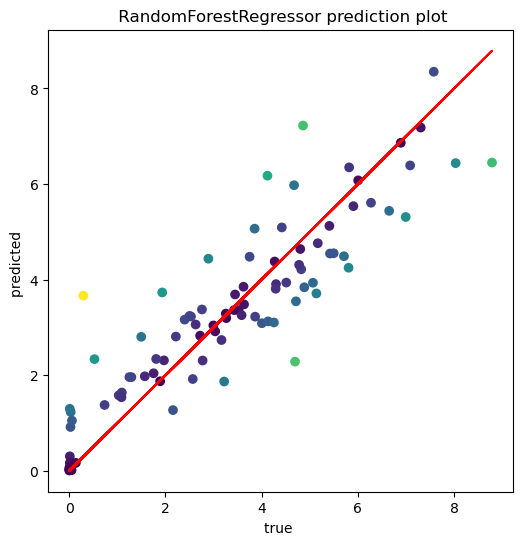

Training scores:
MAE = 0.7018
MSE = 0.9119
RMSE = 0.9549
r^2 = 0.8203


In [6]:
plot_prediction(X_test, y_test, rf, save='models/rf/bg_id/rf_hse06_bg_id_plot.png', format='png')

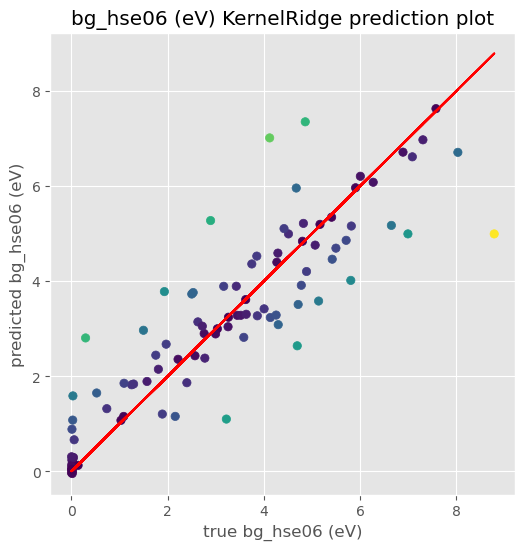

Training scores:
MAE = 0.7080
MSE = 1.0318
RMSE = 1.0158
r^2 = 0.7967


In [66]:
plot_prediction(X_test, y_test, kr, save='models/kr/bg_id/kr_hse06_bg_id_plot.png', format='png')

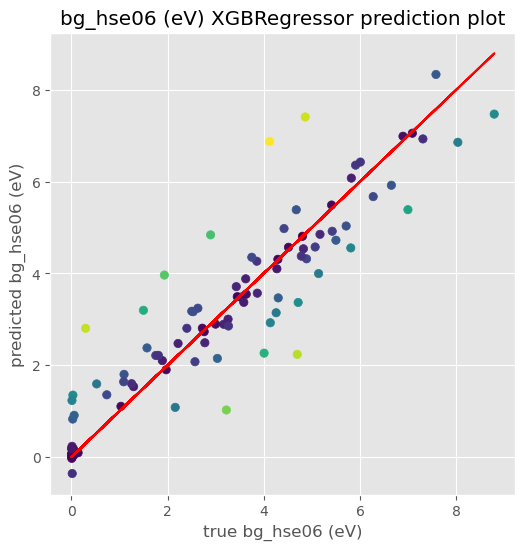

Training scores:
MAE = 0.6325
MSE = 0.8141
RMSE = 0.9023
r^2 = 0.8396


In [68]:
plot_prediction(X_test, y_test, xgb, save='models/xgb/bg_id/xgb_hse06_bg_id_plot.png', format='png')

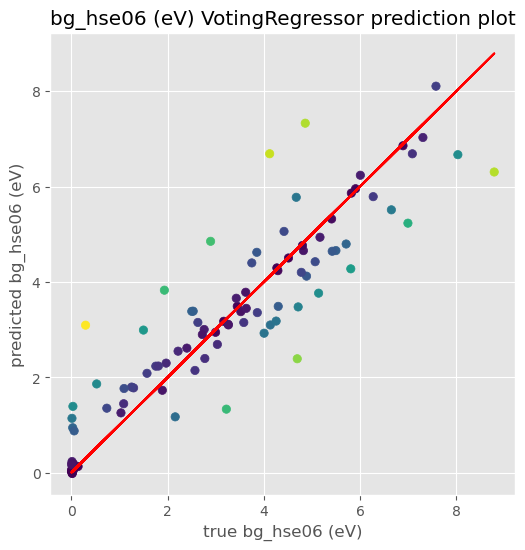

Training scores:
MAE = 0.6458
MSE = 0.8558
RMSE = 0.9251
r^2 = 0.8313


In [70]:
plot_prediction(X_test, y_test, com, save='models/com/bg_id/com_hse06_bg_id_plot.png', format='png')

# AL Query strategies

In [7]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import RandomSampling
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_rnd(
    model,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Random sampling active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
                
            if len(unlabeled_idx) == 0:    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx = rnd.query(X=X_train, y=y_pool, batch_size=batch_size)
            
            y_pool[query_idx] = y_train[query_idx]
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [17]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_unc(
    model,
    bagging_estimators=5,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee Bagging Regressor) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        bagging_estimators: Number of estimators in the bagging committee (int).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                BaggingRegressor(
                    estimator=reg,   
                    n_estimators=bagging_estimators,
                    bootstrap=True,
                    random_state=random_state,
                )
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [18]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_qbc(
    model,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee with heterogeneous models) active learning loop over a regression task.

    Args:
        models: Committee models of several base estimators (sklearn VotingRegressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                estimator=reg, random_state=random_state
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [73]:
from sklearn.base import clone
from skactiveml.regressor import SklearnRegressor
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def diversity_query(
    X_train: np.ndarray,
    y_pool: np.ndarray,
    batch_size: int,
):
    '''
    Select a batch of unlabeled samples using greedy MaxMin diversity sampling with Tanimoto distance.

    Args:
        X_train: Training feature matrix with only fingerprints (np.ndarray).
        y_pool: Current label pool. Unlabeled entries are marked with MISSING_LABEL (np.ndarray).
        batch_size: Number of samples to select (int).
    Returns:
        query_idx: Queried indices, ordered from most to least diverse (np.ndarray).
        utilities:
            - div_mean_pool: Mean Tanimoto distance of all unlabeled points to their nearest labeled neighbour.
            - div_max_pool: Maximum Tanimoto distance in the unlabeled pool, i.e. the distance of the most underexplored point.
    '''
    labeled_idx   = labeled_indices(y_pool)
    unlabeled_idx = unlabeled_indices(y_pool)

    if len(unlabeled_idx) == 0:
        return np.array([], dtype=int), {}

    actual_batch = min(batch_size, len(unlabeled_idx))

    # binarize once, float32 halves memory + speeds up BLAS
    X_u = (X_train[unlabeled_idx] > 0).astype(np.float32)
    X_l = (X_train[labeled_idx]   > 0).astype(np.float32)

    # precompute norms once — reused in every greedy step
    norms_u = X_u.sum(axis=1)  # (n_unlabeled,)
    norms_l = X_l.sum(axis=1)  # (n_labeled,)

    # initial max similarity to labeled set — single matmul
    dot   = X_u @ X_l.T                              # (n_u, n_l)
    union = norms_u[:, None] + norms_l[None, :] - dot
    np.maximum(union, 1e-10, out=union)               # in-place, no allocation
    max_sim = (dot / union).max(axis=1)               # (n_u,)
    del dot, union                                    # free memory immediately

    dist_orig = 1.0 - max_sim.copy()

    selected_local: list[int] = []

    for _ in range(actual_batch):
        best = int(np.argmin(max_sim))
        selected_local.append(best)
        max_sim[best] = np.inf

        if len(selected_local) < actual_batch:
            # matvec (n_u × d) instead of matmul (n_u × n_u) — much cheaper
            dot_new   = X_u @ X_u[best]              # (n_u,)
            union_new = norms_u + norms_u[best] - dot_new
            np.maximum(union_new, 1e-10, out=union_new)
            np.maximum(max_sim, dot_new / union_new, out=max_sim)

    utilities = {
        'mean_diversity': float(dist_orig.mean()),
        'max_diversity':  float(dist_orig.max()),
    }

    return unlabeled_idx[np.array(selected_local)], utilities
    
def al_loop_div(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Diversity sampling (Tanimoto distance) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_diversity': [],
            'max_diversity': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:    
                history['mean_diversity'].append(0.0)
                history['max_diversity'].append(0.0)
                
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Diversity — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx, utilities = diversity_query(X_train[:, (slice(len(features), None))], y_pool, batch_size)
            
            y_pool[query_idx] = y_train[query_idx]

            history['mean_diversity'].append(utilities['mean_diversity'])
            history['max_diversity'].append(utilities['max_diversity'])
            
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Diversity — mean: {utilities['mean_diversity']:.4f}  '
                f'max: {utilities['max_diversity']:.4f}'
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [15]:
al_loop_rnd(rf, n_runs=5, save='active_learning/rf/bg_id/al_history_rf_rnd_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.1836 eV | RMSE: 1.4642 eV | R2: 0.5775 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.9569 eV | RMSE: 1.2751 eV | R2: 0.6796 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.8851 eV | RMSE: 1.2511 eV | R2: 0.6915 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.7892 eV | RMSE: 1.1058 eV | R2: 0.7590 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.7728 eV | RMSE: 1.0983 eV | R2: 0.7623 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.8080 eV | RMSE: 1.0781 eV | R2: 0.7709 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.7234 eV | RMSE: 1.0165 eV | R2: 0.7964 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.7313 eV | RMSE: 1.0197 eV | R2: 0.7951 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.7191 eV | RMSE: 1.0034 eV | R2: 0.8016 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.6946 eV | RMSE: 0.9588 eV | R2: 0.8188 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.7018 eV | RMSE: 0.9549 eV | R2: 0.8203 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,1.183556,2.144021,1.464248,0.577467,1.272747,2.498615,1.580701,0.489492,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.956867,1.625809,1.275072,0.679593,1.060903,1.992890,1.411698,0.592820,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.885127,1.565304,1.251121,0.691517,1.010785,1.968203,1.402927,0.597864,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.789219,1.222868,1.105834,0.759003,0.916548,1.587622,1.260009,0.675623,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.772762,1.206240,1.098290,0.762280,0.933710,1.658794,1.287942,0.661081,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.807967,1.162258,1.078080,0.770948,0.915381,1.584129,1.258622,0.676337,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.723447,1.033266,1.016497,0.796369,0.935451,1.663871,1.289911,0.660044,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.731277,1.039715,1.019664,0.795098,0.875457,1.538436,1.240337,0.685672,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.719084,1.006829,1.003409,0.801579,0.885675,1.549278,1.244700,0.683457,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.694600,0.919301,0.958802,0.818828,0.933865,1.687783,1.299147,0.655158,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [19]:
al_loop_unc(rf, n_runs=5, save='active_learning/rf/bg_id/al_history_rf_unc_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.1836 eV | RMSE: 1.4642 eV | R2: 0.5775 | Uncertainty — mean: 0.9814 eV  max: 1.1489 eV
Cycle  2 | Labeled:   130/760 | MAE: 1.0062 eV | RMSE: 1.3116 eV | R2: 0.6610 | Uncertainty — mean: 0.8340 eV  max: 1.0480 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.9466 eV | RMSE: 1.2367 eV | R2: 0.6986 | Uncertainty — mean: 0.7579 eV  max: 0.9902 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.8778 eV | RMSE: 1.1707 eV | R2: 0.7299 | Uncertainty — mean: 0.7055 eV  max: 0.9423 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.8160 eV | RMSE: 1.0977 eV | R2: 0.7625 | Uncertainty — mean: 0.6480 eV  max: 0.8595 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.7478 eV | RMSE: 1.0022 eV | R2: 0.8021 | Uncertainty — mean: 0.5917 eV  max: 0.8636 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.7688 eV | RMSE: 1.0242 eV | R2: 0.7933 | Uncertainty — mean: 0.5658 eV  max: 0.6898 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.7178 eV | RMSE: 0.9932 eV | R2: 0.8056 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,1.183556,2.144021,1.464248,0.577467,1.272747,2.498615,1.580701,0.489492,0.963078,1.320011,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,1.006231,1.720277,1.311593,0.660976,1.162060,2.165395,1.471528,0.557574,0.695614,1.098293,"[37, 711, 256, 709, 123, 591, 468, 749, 92, 42..."
2,1,3,200,0.946647,1.529381,1.236681,0.698597,1.101885,2.024021,1.422681,0.586459,0.574398,0.980488,"[97, 629, 577, 721, 388, 124, 326, 644, 368, 4..."
3,1,4,270,0.877766,1.370497,1.170682,0.729909,1.105907,2.028123,1.424122,0.585621,0.497707,0.888010,"[235, 268, 613, 255, 318, 633, 94, 43, 63, 406..."
4,1,5,340,0.816002,1.204944,1.097699,0.762535,1.046015,1.801048,1.342031,0.632016,0.419862,0.738661,"[105, 750, 10, 650, 718, 136, 144, 238, 13, 42..."
5,1,6,410,0.747801,1.004362,1.002179,0.802065,0.996913,1.674903,1.294180,0.657790,0.350115,0.745891,"[517, 28, 316, 85, 561, 708, 275, 174, 155, 72..."
6,1,7,480,0.768779,1.049059,1.024236,0.793256,0.938106,1.559372,1.248748,0.681395,0.320097,0.475774,"[684, 407, 385, 173, 746, 470, 597, 678, 366, ..."
7,1,8,550,0.717807,0.986363,0.993158,0.805612,0.915035,1.591627,1.261597,0.674805,0.270073,0.662791,"[507, 260, 264, 687, 166, 355, 348, 246, 664, ..."
8,1,9,620,0.735236,0.986573,0.993264,0.805571,0.910021,1.547188,1.243860,0.683884,0.196837,0.642735,"[164, 676, 505, 298, 80, 99, 671, 189, 184, 73..."
9,1,10,690,0.694353,0.896793,0.946992,0.823264,0.906473,1.602455,1.265881,0.672592,0.084519,0.246838,"[707, 287, 383, 500, 284, 380, 445, 149, 390, ..."


In [27]:
al_loop_rnd(xgb, n_runs=5, save='active_learning/xgb/bg_id/al_history_xgb_rnd_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0404 eV | RMSE: 1.3832 eV | R2: 0.6229 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.9331 eV | RMSE: 1.2177 eV | R2: 0.7078 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.8711 eV | RMSE: 1.2101 eV | R2: 0.7114 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.7969 eV | RMSE: 1.0866 eV | R2: 0.7673 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.7353 eV | RMSE: 1.0626 eV | R2: 0.7775 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.7647 eV | RMSE: 1.0728 eV | R2: 0.7732 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.7093 eV | RMSE: 1.0180 eV | R2: 0.7958 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.6714 eV | RMSE: 0.9164 eV | R2: 0.8345 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.6666 eV | RMSE: 0.9268 eV | R2: 0.8307 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.6279 eV | RMSE: 0.9098 eV | R2: 0.8369 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.6690 eV | RMSE: 0.9265 eV | R2: 0.8308 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,1.040395,1.913317,1.383227,0.622933,1.164878,2.202251,1.483998,0.550044,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.933061,1.482710,1.217666,0.707795,1.075392,2.205458,1.485078,0.549389,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.871063,1.464314,1.210088,0.711420,0.998872,2.008526,1.417225,0.589625,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.796946,1.180743,1.086620,0.767305,0.927679,1.701139,1.304277,0.652430,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.735285,1.129173,1.062626,0.777468,0.901248,1.691536,1.300590,0.654392,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.764706,1.150943,1.072820,0.773178,0.915767,1.696664,1.302561,0.653344,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.709263,1.036249,1.017963,0.795781,0.863886,1.566412,1.251564,0.679956,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.671379,0.839830,0.916423,0.834490,0.882612,1.577715,1.256071,0.677647,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.666622,0.858952,0.926797,0.830722,0.886167,1.576906,1.255749,0.677812,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.627931,0.827733,0.909798,0.836874,0.837717,1.449328,1.203880,0.703879,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [28]:
al_loop_unc(xgb, n_runs=5, save='active_learning/xgb/bg_id/al_history_xgb_unc_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0404 eV | RMSE: 1.3832 eV | R2: 0.6229 | Uncertainty — mean: 1.1227 eV  max: 1.2558 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.8925 eV | RMSE: 1.1851 eV | R2: 0.7232 | Uncertainty — mean: 0.9116 eV  max: 1.2397 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.8867 eV | RMSE: 1.1891 eV | R2: 0.7214 | Uncertainty — mean: 0.8219 eV  max: 1.1192 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.7850 eV | RMSE: 1.0278 eV | R2: 0.7918 | Uncertainty — mean: 0.8195 eV  max: 1.1416 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.7330 eV | RMSE: 1.0171 eV | R2: 0.7961 | Uncertainty — mean: 0.7150 eV  max: 0.9244 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.7457 eV | RMSE: 1.0073 eV | R2: 0.8000 | Uncertainty — mean: 0.6938 eV  max: 0.8777 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.7330 eV | RMSE: 1.0017 eV | R2: 0.8023 | Uncertainty — mean: 0.6589 eV  max: 0.8345 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.6577 eV | RMSE: 0.9153 eV | R2: 0.8349 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,1.040395,1.913317,1.383227,0.622933,1.164878,2.202251,1.483998,0.550044,1.260357,1.576974,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.892485,1.404444,1.185092,0.723219,1.192579,2.490967,1.578280,0.491055,0.831103,1.536976,"[205, 749, 29, 646, 250, 354, 534, 248, 711, 3..."
2,1,3,200,0.886706,1.413883,1.189068,0.721359,1.045779,1.904093,1.379889,0.610963,0.675461,1.252573,"[589, 296, 629, 721, 326, 543, 486, 428, 754, ..."
3,1,4,270,0.785005,1.056310,1.027770,0.791827,0.936939,1.580538,1.257194,0.677070,0.671598,1.303291,"[268, 645, 517, 107, 361, 598, 705, 51, 706, 3..."
4,1,5,340,0.732974,1.034400,1.017054,0.796145,0.908040,1.547908,1.244150,0.683737,0.511261,0.854600,"[323, 148, 220, 479, 549, 254, 684, 731, 374, ..."
5,1,6,410,0.745669,1.014656,1.007302,0.800036,0.943273,1.628533,1.276140,0.667264,0.481330,0.770382,"[159, 210, 424, 396, 186, 172, 171, 407, 117, ..."
6,1,7,480,0.733038,1.003339,1.001668,0.802267,0.898790,1.507008,1.227603,0.692094,0.434140,0.696394,"[702, 434, 19, 88, 61, 180, 134, 10, 196, 256,..."
7,1,8,550,0.657655,0.837777,0.915302,0.834895,0.857329,1.393646,1.180528,0.715255,0.337427,0.507336,"[273, 164, 482, 470, 311, 153, 508, 236, 11, 1..."
8,1,9,620,0.664677,0.870879,0.933209,0.828371,0.861602,1.408414,1.186766,0.712238,0.263017,0.511175,"[441, 678, 640, 542, 398, 346, 200, 559, 701, ..."
9,1,10,690,0.657563,0.846800,0.920217,0.833117,0.830361,1.342712,1.158754,0.725662,0.145059,0.395382,"[540, 262, 400, 182, 425, 450, 17, 58, 740, 49..."


In [29]:
al_loop_rnd(kr, n_runs=5, save='active_learning/kr/bg_id/al_history_kr_rnd_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0777 eV | RMSE: 1.4364 eV | R2: 0.5934 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.9190 eV | RMSE: 1.2544 eV | R2: 0.6899 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.9233 eV | RMSE: 1.2999 eV | R2: 0.6670 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.8598 eV | RMSE: 1.2152 eV | R2: 0.7090 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.8425 eV | RMSE: 1.1836 eV | R2: 0.7239 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.8421 eV | RMSE: 1.1844 eV | R2: 0.7235 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.7935 eV | RMSE: 1.1059 eV | R2: 0.7590 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.7430 eV | RMSE: 1.0307 eV | R2: 0.7906 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.7360 eV | RMSE: 1.0239 eV | R2: 0.7934 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.7186 eV | RMSE: 1.0117 eV | R2: 0.7983 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.7080 eV | RMSE: 1.0158 eV | R2: 0.7967 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,1.077690,2.063285,1.436414,0.593378,1.194856,2.384888,1.544308,0.512728,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.918957,1.573557,1.254415,0.689891,1.112665,2.108373,1.452024,0.569225,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.923304,1.689692,1.299882,0.667004,1.057015,2.046578,1.430586,0.581851,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.859789,1.476679,1.215187,0.708983,0.961278,1.714496,1.309388,0.649700,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.842473,1.401026,1.183649,0.723893,0.955289,1.696918,1.302658,0.653292,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.842131,1.402839,1.184415,0.723535,0.916057,1.665105,1.290390,0.659792,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.793484,1.223077,1.105928,0.758962,0.892907,1.565733,1.251292,0.680095,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.742967,1.062410,1.030733,0.790625,0.862177,1.540698,1.241248,0.685210,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.736041,1.048272,1.023851,0.793412,0.865225,1.522936,1.234073,0.688839,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.718637,1.023479,1.011671,0.798298,0.850945,1.500164,1.224812,0.693492,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [30]:
al_loop_unc(kr, n_runs=5, save='active_learning/kr/bg_id/al_history_kr_unc_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0777 eV | RMSE: 1.4364 eV | R2: 0.5934 | Uncertainty — mean: 0.9084 eV  max: 1.2690 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.9216 eV | RMSE: 1.2464 eV | R2: 0.6938 | Uncertainty — mean: 0.6747 eV  max: 0.7961 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.8968 eV | RMSE: 1.2282 eV | R2: 0.7027 | Uncertainty — mean: 0.6739 eV  max: 0.7742 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.9147 eV | RMSE: 1.2192 eV | R2: 0.7071 | Uncertainty — mean: 0.6598 eV  max: 0.7992 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.9156 eV | RMSE: 1.2360 eV | R2: 0.6989 | Uncertainty — mean: 0.6787 eV  max: 0.8857 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.8467 eV | RMSE: 1.1800 eV | R2: 0.7256 | Uncertainty — mean: 0.6605 eV  max: 0.9295 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.8128 eV | RMSE: 1.1308 eV | R2: 0.7480 | Uncertainty — mean: 0.6043 eV  max: 0.9497 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.7708 eV | RMSE: 1.0895 eV | R2: 0.7661 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,1.077690,2.063285,1.436414,0.593378,1.194856,2.384888,1.544308,0.512728,0.825100,1.610255,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.921585,1.553575,1.246425,0.693829,1.152399,2.130532,1.459634,0.564698,0.455213,0.633771,"[341, 749, 556, 382, 626, 256, 273, 93, 377, 1..."
2,1,3,200,0.896788,1.508583,1.228244,0.702696,1.037965,1.848592,1.359629,0.622302,0.454194,0.599347,"[600, 346, 437, 642, 484, 136, 176, 401, 549, ..."
3,1,4,270,0.914740,1.486328,1.219151,0.707082,1.022875,1.817583,1.348178,0.628638,0.435306,0.638711,"[148, 611, 709, 708, 51, 485, 227, 4, 21, 561,..."
4,1,5,340,0.915569,1.527680,1.235994,0.698932,0.998731,1.775568,1.332504,0.637222,0.460673,0.784390,"[112, 319, 402, 76, 68, 748, 183, 533, 475, 46..."
5,1,6,410,0.846674,1.392504,1.180044,0.725572,0.969354,1.680976,1.296524,0.656549,0.436314,0.863961,"[184, 641, 414, 126, 245, 658, 274, 299, 421, ..."
6,1,7,480,0.812818,1.278820,1.130849,0.747976,0.939776,1.581462,1.257562,0.676881,0.365137,0.902013,"[347, 94, 234, 604, 125, 568, 644, 392, 497, 7..."
7,1,8,550,0.770840,1.187035,1.089511,0.766065,0.934166,1.571326,1.253526,0.678952,0.287893,0.584832,"[633, 320, 54, 31, 179, 481, 77, 487, 634, 182..."
8,1,9,620,0.728678,1.123868,1.060127,0.778513,0.890271,1.469019,1.212031,0.699855,0.206557,0.423866,"[71, 235, 731, 557, 651, 543, 180, 22, 57, 16,..."
9,1,10,690,0.724461,1.069821,1.034322,0.789165,0.876002,1.447829,1.203258,0.704185,0.128046,0.367217,"[266, 38, 670, 470, 282, 547, 378, 70, 461, 70..."


In [31]:
al_loop_rnd(com, n_runs=5, save='active_learning/com/bg_id/al_history_com_rnd_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0204 eV | RMSE: 1.3624 eV | R2: 0.6342 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.8890 eV | RMSE: 1.2015 eV | R2: 0.7155 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.8455 eV | RMSE: 1.2125 eV | R2: 0.7103 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.7858 eV | RMSE: 1.1041 eV | R2: 0.7597 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.7627 eV | RMSE: 1.0810 eV | R2: 0.7697 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.7651 eV | RMSE: 1.0807 eV | R2: 0.7698 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.7110 eV | RMSE: 1.0101 eV | R2: 0.7989 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.6926 eV | RMSE: 0.9783 eV | R2: 0.8114 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.6819 eV | RMSE: 0.9685 eV | R2: 0.8151 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.6517 eV | RMSE: 0.9406 eV | R2: 0.8256 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.6472 eV | RMSE: 0.9291 eV | R2: 0.8299 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,1.020384,1.856185,1.362419,0.634192,1.164335,2.226035,1.491990,0.545185,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.889044,1.443509,1.201461,0.715520,1.048690,2.001974,1.414911,0.590964,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.845454,1.470220,1.212526,0.710256,0.982390,1.911194,1.382459,0.609512,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.785807,1.219124,1.104140,0.759741,0.901682,1.593026,1.262151,0.674519,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.762683,1.168638,1.081036,0.769690,0.909371,1.615457,1.271006,0.669936,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.765091,1.167949,1.080717,0.769826,0.889552,1.597880,1.264073,0.673527,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.711014,1.020266,1.010082,0.798931,0.873602,1.533898,1.238506,0.686600,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.692626,0.957101,0.978315,0.811379,0.847378,1.479887,1.216506,0.697635,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.681920,0.938087,0.968549,0.815126,0.846580,1.460857,1.208659,0.701523,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.651699,0.884700,0.940585,0.825648,0.859893,1.490685,1.220936,0.695429,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [32]:
al_loop_qbc(com, n_runs=5, save='active_learning/com/bg_id/al_history_com_unc_hse_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 1.0204 eV | RMSE: 1.3624 eV | R2: 0.6342 | Uncertainty — mean: 0.9156 eV  max: 1.1801 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.9525 eV | RMSE: 1.2679 eV | R2: 0.6832 | Uncertainty — mean: 0.7688 eV  max: 1.0895 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.8895 eV | RMSE: 1.2150 eV | R2: 0.7091 | Uncertainty — mean: 0.7237 eV  max: 0.9403 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.8111 eV | RMSE: 1.1090 eV | R2: 0.7576 | Uncertainty — mean: 0.6492 eV  max: 0.8079 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.7389 eV | RMSE: 1.0334 eV | R2: 0.7895 | Uncertainty — mean: 0.5848 eV  max: 0.7140 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.7033 eV | RMSE: 0.9888 eV | R2: 0.8073 | Uncertainty — mean: 0.5383 eV  max: 0.7241 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.6594 eV | RMSE: 0.9379 eV | R2: 0.8266 | Uncertainty — mean: 0.5088 eV  max: 0.6985 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.6628 eV | RMSE: 0.9388 eV | R2: 0.8263 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,1.020384,1.856185,1.362419,0.634192,1.164335,2.226035,1.491990,0.545185,0.838391,1.392735,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.952461,1.607671,1.267940,0.683168,1.135679,2.292105,1.513970,0.531686,0.591006,1.187061,"[737, 402, 372, 334, 86, 523, 301, 74, 160, 70..."
2,1,3,200,0.889525,1.476196,1.214988,0.709078,1.071152,2.061570,1.435817,0.578788,0.523736,0.884164,"[711, 543, 119, 244, 368, 197, 635, 387, 65, 4..."
3,1,4,270,0.811075,1.229967,1.109039,0.757604,0.944799,1.663449,1.289748,0.660130,0.421518,0.652700,"[678, 282, 626, 341, 388, 237, 55, 612, 235, 5..."
4,1,5,340,0.738879,1.068003,1.033442,0.789523,0.938541,1.625753,1.275050,0.667832,0.342045,0.509807,"[712, 542, 146, 255, 684, 134, 211, 598, 556, ..."
5,1,6,410,0.703266,0.977667,0.988770,0.807326,0.869211,1.424282,1.193433,0.708996,0.289761,0.524335,"[517, 27, 253, 650, 568, 200, 389, 75, 535, 61..."
6,1,7,480,0.659433,0.879636,0.937889,0.826646,0.852997,1.361400,1.166790,0.721844,0.258892,0.487951,"[367, 130, 506, 459, 96, 164, 23, 177, 453, 72..."
7,1,8,550,0.662843,0.881288,0.938769,0.826320,0.828907,1.330780,1.153594,0.728100,0.203994,0.352263,"[22, 124, 500, 128, 682, 292, 646, 236, 28, 17..."
8,1,9,620,0.661954,0.892511,0.944728,0.824108,0.862662,1.374166,1.172248,0.719235,0.156525,0.271160,"[329, 616, 528, 105, 273, 672, 129, 529, 432, ..."
9,1,10,690,0.661435,0.889245,0.942998,0.824752,0.827901,1.337360,1.156443,0.726755,0.087113,0.237464,"[424, 412, 30, 308, 466, 114, 442, 186, 381, 4..."


In [21]:
def df_groupby(df):
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

In [34]:
rf_unc = df_groupby(pd.read_csv('active_learning/rf/bg_id/al_history_rf_unc_hse_bg_id.csv'))
rf_rnd = df_groupby(pd.read_csv('active_learning/rf/bg_id/al_history_rf_rnd_hse_bg_id.csv'))
# rf_div = df_groupby(pd.read_csv('active_learning/rf/hse_df_feat/al_history_rf_div_dH_hse_df_feat.csv'))
xgb_unc = df_groupby(pd.read_csv('active_learning/xgb/bg_id/al_history_xgb_unc_hse_bg_id.csv'))
xgb_rnd = df_groupby(pd.read_csv('active_learning/xgb/bg_id/al_history_xgb_rnd_hse_bg_id.csv'))
# xgb_div = df_groupby(pd.read_csv('active_learning/xgb/hse_df_feat/al_history_xgb_div_dH_hse_df_feat.csv'))
kr_unc = df_groupby(pd.read_csv('active_learning/kr/bg_id/al_history_kr_unc_hse_bg_id.csv'))
kr_rnd = df_groupby(pd.read_csv('active_learning/kr/bg_id/al_history_kr_rnd_hse_bg_id.csv'))
# kr_div = df_groupby(pd.read_csv('active_learning/kr/hse_df_feat/al_history_kr_div_dH_hse_df_feat.csv'))
com_unc = df_groupby(pd.read_csv('active_learning/com/bg_id/al_history_com_unc_hse_bg_id.csv'))
com_rnd = df_groupby(pd.read_csv('active_learning/com/bg_id/al_history_com_rnd_hse_bg_id.csv'))
# com_div = df_groupby(pd.read_csv('active_learning/com/hse_df_feat/al_history_com_div_dH_hse_df_feat.csv'))

In [24]:
def plot_al(dfs, labels, score, save=None, format='pdf'):
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
            )
            ax.fill_between(
                df['n_labeled'],
                df[f'min_{key}'],
                df[f'max_{key}'],
                alpha=0.2,
                color=color,
            )

        # Plot the baseline reference line
        baseline_val = score[key]
        ax.axhline(
            baseline_val,
            color='black',
            ls='--',
            label=f'full = {baseline_val:.4f}',
        )

        ax.set(xlabel='Labeled samples', ylabel=label, title=label)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

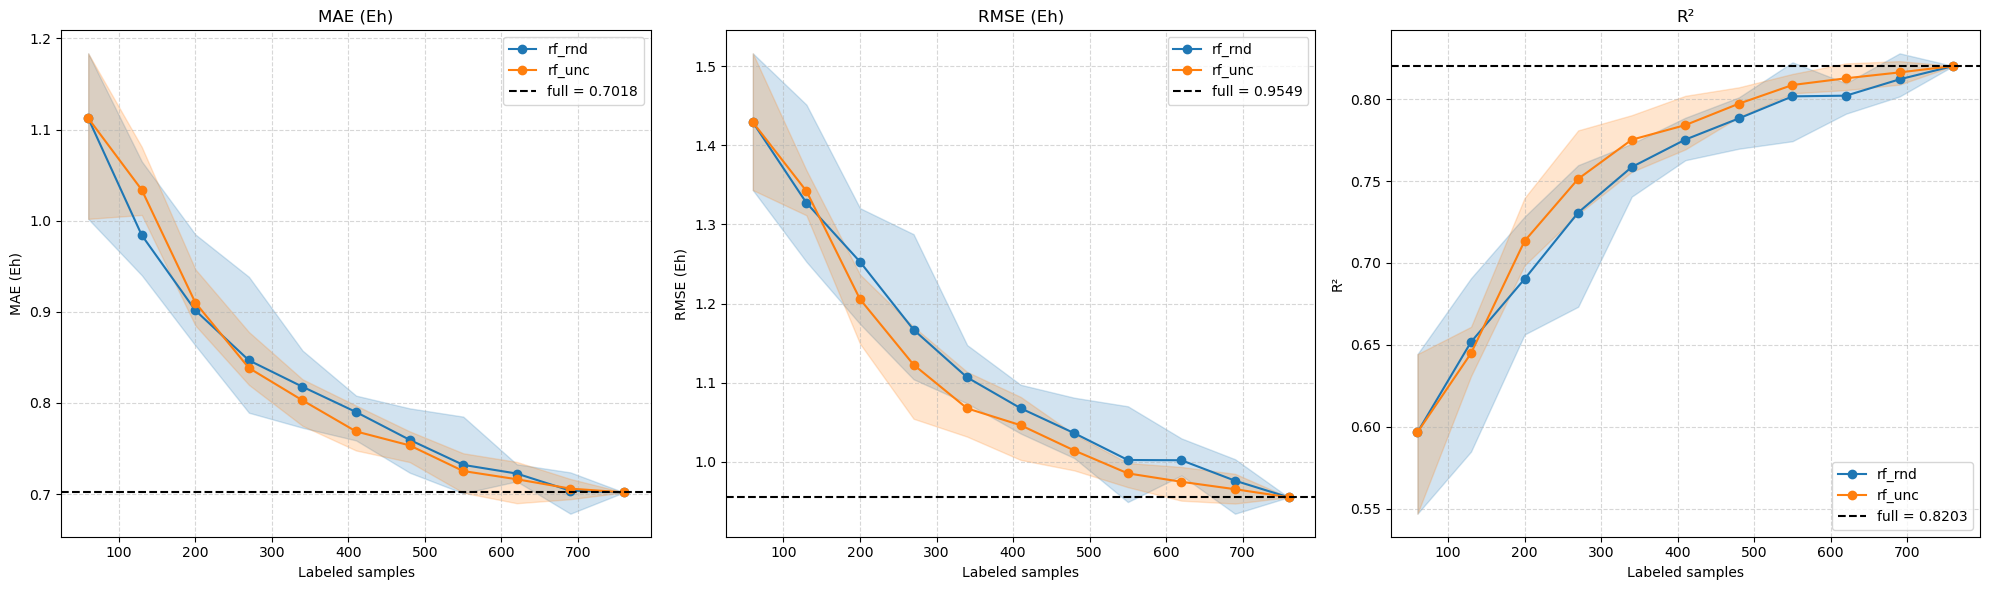

In [36]:
plot_al([rf_rnd, rf_unc], ['rf_rnd','rf_unc'], rf_score, save='active_learning/rf/bg_id/al_rf_hse_bg_id.png', format='png')

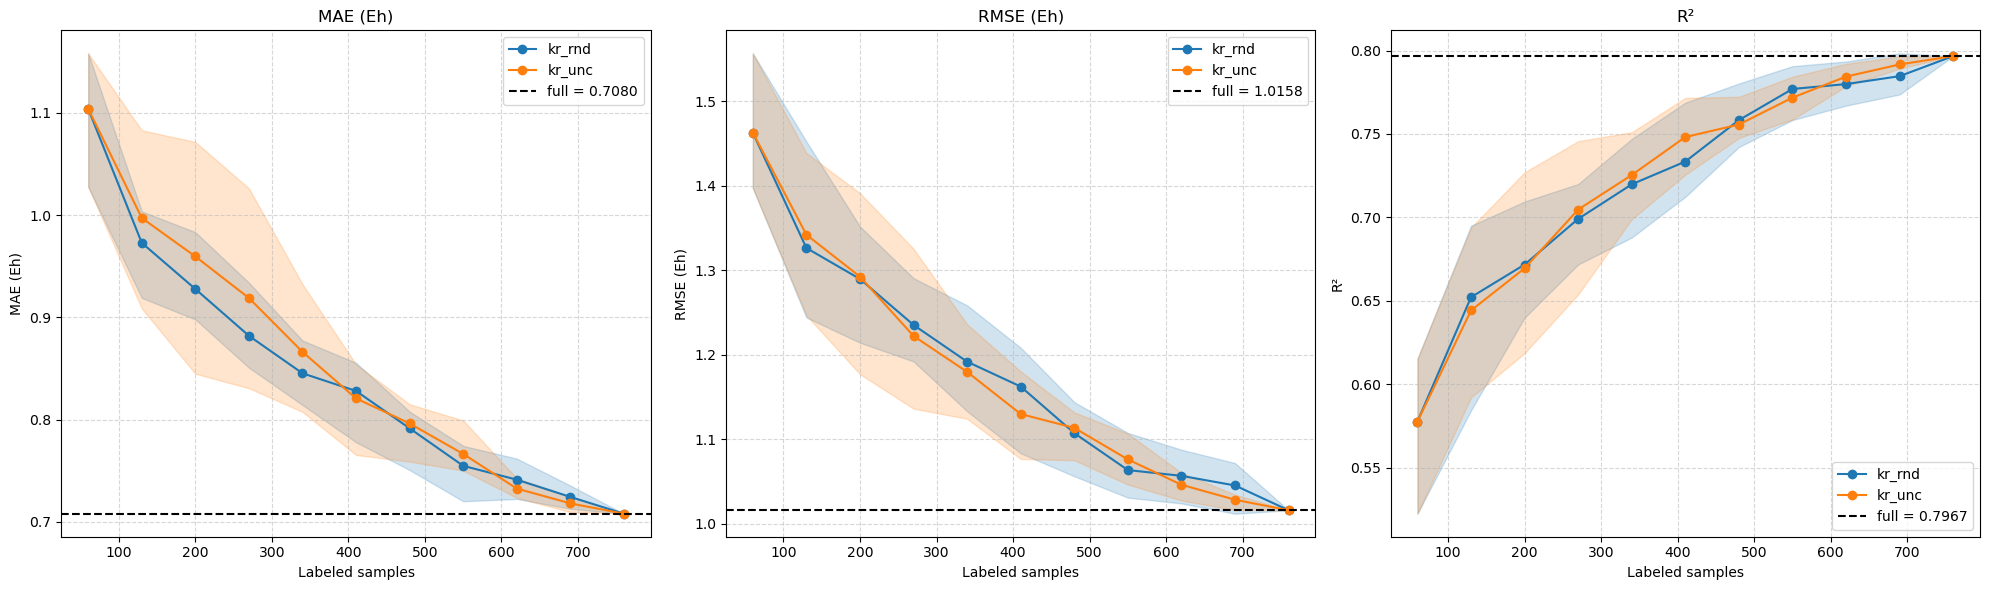

In [38]:
plot_al([kr_rnd, kr_unc], ['kr_rnd','kr_unc'], kr_score, save='active_learning/kr/bg_id/al_kr_hse_bg_id.png', format='png')

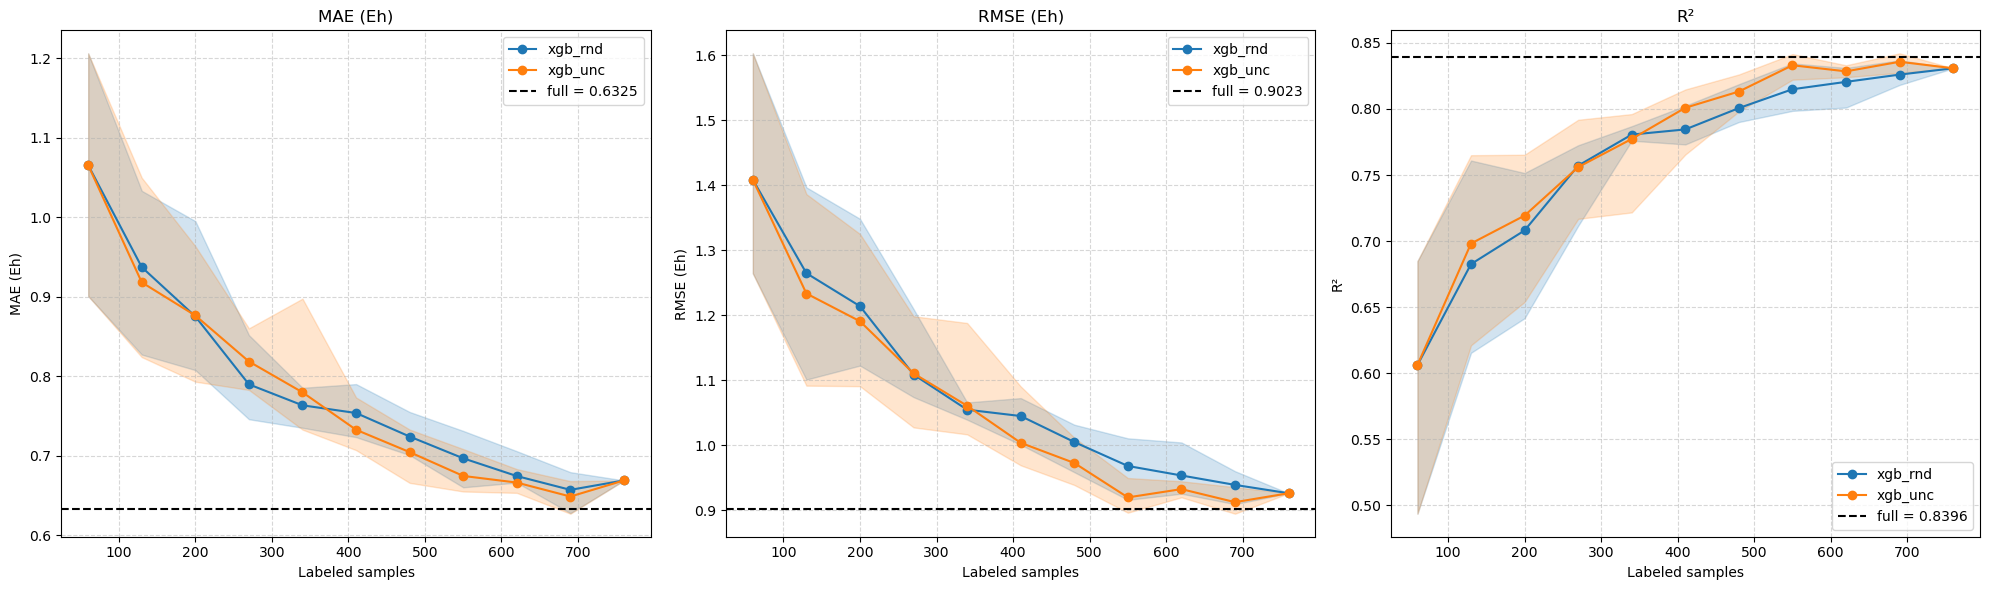

In [40]:
plot_al([xgb_rnd, xgb_unc], ['xgb_rnd','xgb_unc'], xgb_score, save='active_learning/xgb/bg_id/al_xgb_hse_bg_id.png', format='png')

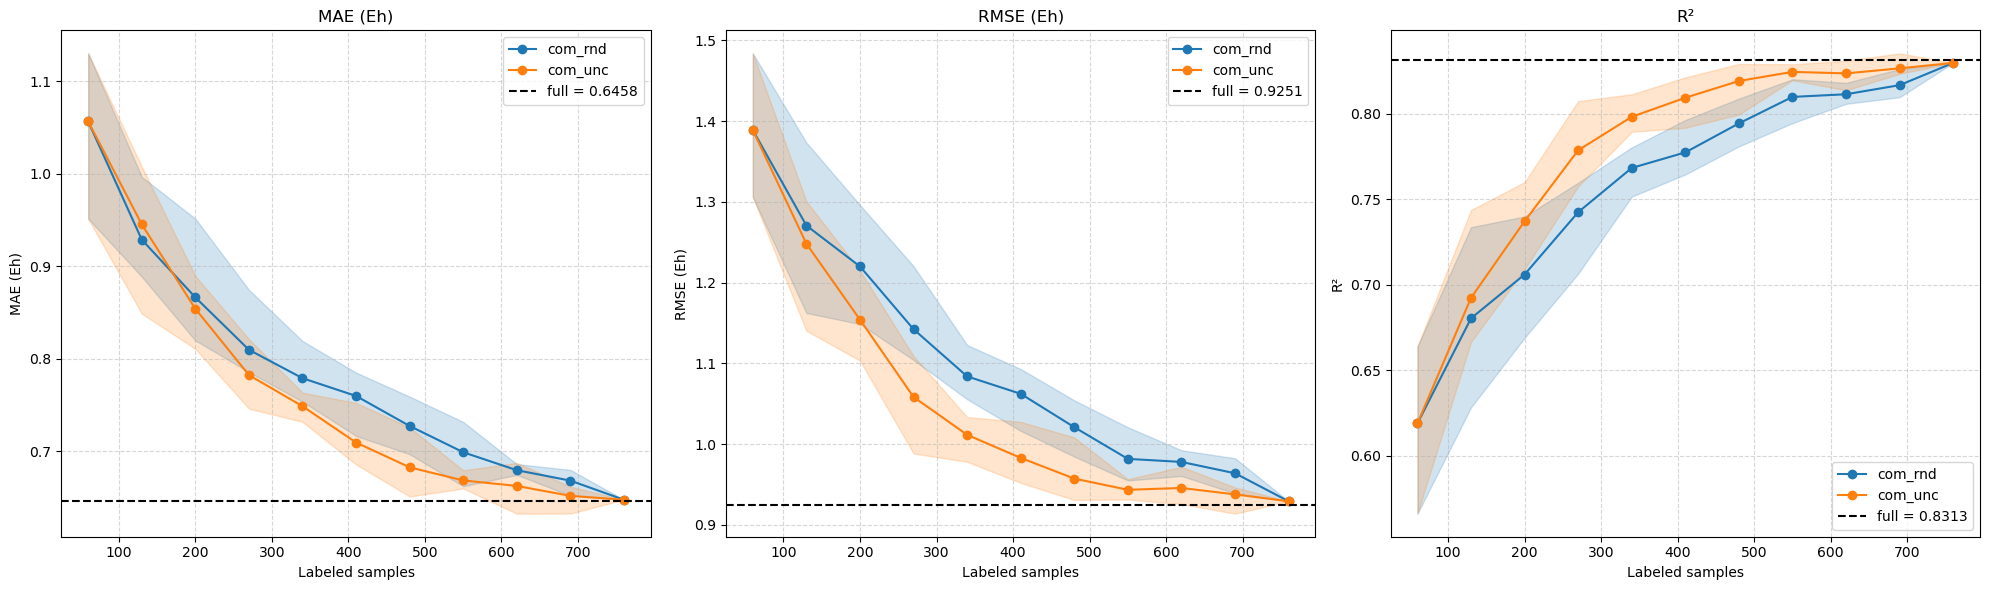

In [42]:
plot_al([com_rnd, com_unc], ['com_rnd','com_unc'], com_score, save='active_learning/com/bg_id/al_com_hse_bg_id.png', format='png')

In [20]:
import ast
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

print('Computing UMAP projection for X_train...')

reducer = umap.UMAP(
    n_neighbors=10, 
    min_dist=0.25, 
    metric='euclidean', 
    random_state=42
)
X_umap = reducer.fit_transform(X_train)

print('UMAP Projection complete.')

Computing UMAP projection for X_train...
UMAP Projection complete.


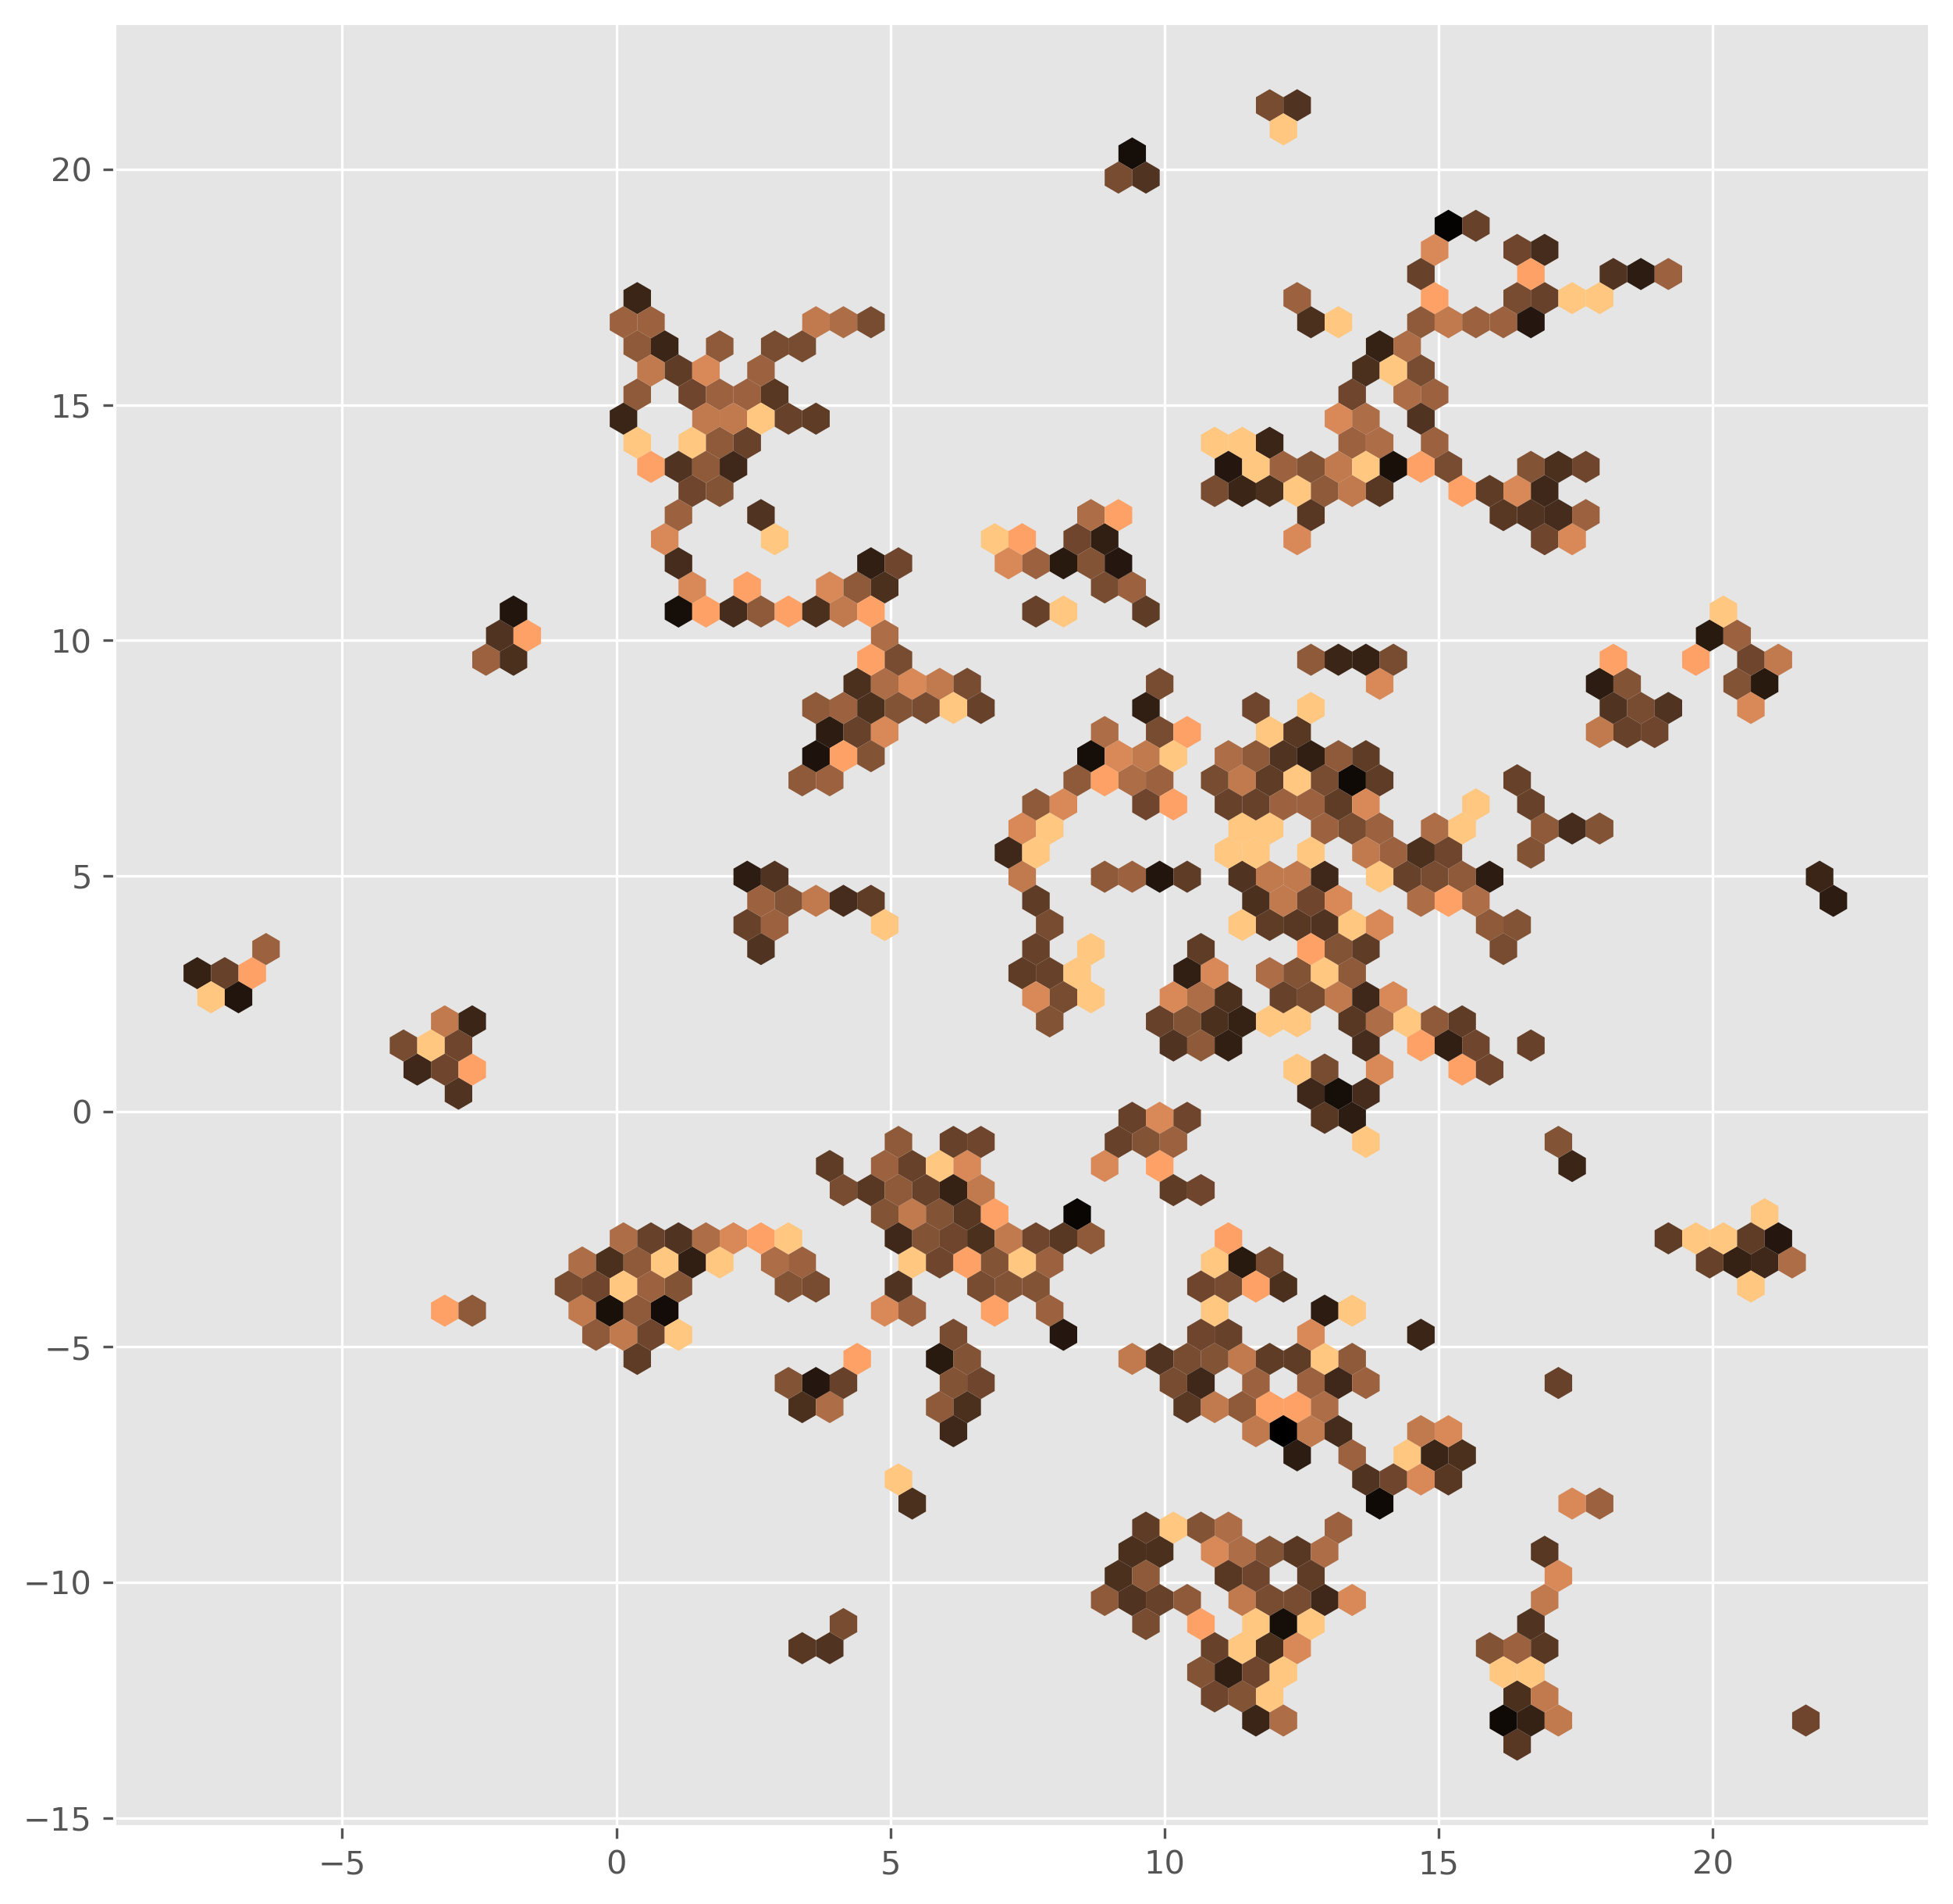

In [21]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

CSV_PATH = 'active_learning/com/hse_df_feat/al_history_com_rnd_dG_hse_df_feat.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/com/hse_df_feat/umap_al_com_rnd_dG_hse_df_feat.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# Initialize a perfect square canvas
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

# Layer 1: Background Density Map (Log scaled)
hb = ax.hexbin(
    X_umap[:, 0],
    X_umap[:, 1],
    gridsize=60,
    cmap='copper_r',
    mincnt=1,
    edgecolors='none',
    norm=colors.LogNorm()
)
plt.show()

In [34]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

# ── PARAMETERS & CONFIGURATION ────────────────────────────────────────────────
CSV_PATH = 'active_learning/xgb/hse_df_feat/al_history_xgb_unc_dG_hse_df_feat.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/xgb/hse_df_feat/umap_al_xgb_unc_dG_hse_df_feat.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# ── MAIN ANIMATION LOOP ───────────────────────────────────────────────────────
frame_files = []

for i, (current_cycle, current_batch) in enumerate(parsed_cycles):
    # Retrieve and separate historically labeled vs. newly queried points
    previous_indices = []
    for cycle_num, indices in parsed_cycles[:i]:
        previous_indices.extend(indices)
    
    total_labeled_count = len(previous_indices) + len(current_batch)

    # Initialize a perfect square canvas
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    
    # Layer 1: Background Density Map (Log scaled)
    hb = ax.hexbin(
        X_umap[:, 0],
        X_umap[:, 1],
        gridsize=60,
        cmap='copper_r',
        mincnt=1,
        edgecolors='none',
        norm=colors.LogNorm()
    )

    # Layer 2: Previously Labeled points (Colored by ground-truth property)
    sc = ax.scatter(
        X_umap[previous_indices, 0],
        X_umap[previous_indices, 1],
        c=y_train[previous_indices],
        cmap='viridis',
        # vmin=0.0,
        # vmax=0.7,
        marker='o',
        edgecolors='none',
        s=10,
        alpha=0.7,
        label='Previously Labeled',
    )

    # Layer 3: Newly Labeled Points (A acquisition target highlighted in pink)
    ax.scatter(
        X_umap[current_batch, 0],
        X_umap[current_batch, 1],
        c='#FF0055',
        marker='o',
        s=4,
        alpha=0.75,
        label='Newly Labeled',
    )

    # Align 1:1 coordinate spans to keep the physical aspect ratio square
    x_min, x_max = X_umap[:, 0].min(), X_umap[:, 0].max()
    y_min, y_max = X_umap[:, 1].min(), X_umap[:, 1].max()
    limit_min = min(x_min, y_min) - 0.5
    limit_max = max(x_max, y_max) + 0.5
    
    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    ax.set_aspect('equal', adjustable='box')

    # Position colorbars using relative canvas coordinates
    ax_cb_horizontal = ax.inset_axes([0.1, -0.07, 0.8, 0.03])
    cb_density = fig.colorbar(hb, cax=ax_cb_horizontal, orientation='horizontal')
    cb_density.set_label('Molecule Density (Count per Hex)', fontsize=10, fontweight='bold')
    
    ax_cb_vertical = ax.inset_axes([1.03, 0.1, 0.03, 0.8])
    cb_gap = fig.colorbar(sc, cax=ax_cb_vertical)
    cb_gap.set_label('dG (eV)', fontsize=10, fontweight='bold')

    # Titles and Legends
    ax.set_title(
        f'QM9 Chemical Space (UMAP)\n'
        f'Run {TARGET_RUN} | Cycle {current_cycle} | {total_labeled_count} Total Labeled',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    
    ax.legend(
        loc='upper right', 
        scatterpoints=1, 
        markerscale=1.5, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=9
    )

    # plt.show()
    # Save current cycle plot frame
    frame_path = os.path.join(FRAME_DIR, f'frame_{current_cycle:03d}.png')
    plt.savefig(frame_path, dpi=150) # Use 150 DPI for faster writing
    plt.close(fig)
    
    frame_files.append(frame_path)
    print(f'Rendered Frame for Cycle {current_cycle}')

# ── STEP 5: COMPILING INDIVIDUAL FRAMES INTO A GIF ───────────────────────────
print("Compiling global GIF animation...")
images = [imageio.imread(f) for f in frame_files]
imageio.mimsave(GIF_OUTPUT, images, fps=FPS)

# Optional cleanup: Delete temporary PNG frame files
for f in frame_files:
    os.remove(f)

print(f"Success! Saved evolution animation to: '{GIF_OUTPUT}'")

Rendered Frame for Cycle 1
Rendered Frame for Cycle 2
Rendered Frame for Cycle 3
Rendered Frame for Cycle 4
Rendered Frame for Cycle 5
Rendered Frame for Cycle 6
Rendered Frame for Cycle 7
Rendered Frame for Cycle 8
Rendered Frame for Cycle 9
Rendered Frame for Cycle 10
Rendered Frame for Cycle 11
Compiling global GIF animation...
Success! Saved evolution animation to: 'active_learning/xgb/hse_df_feat/umap_al_xgb_unc_dG_hse_df_feat.gif'


### Violins plots

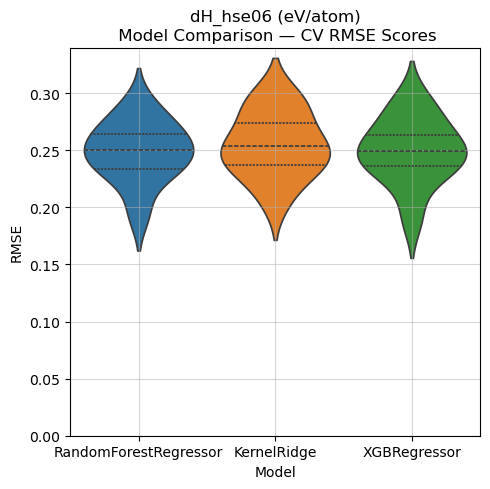

In [34]:
models_1 = [rf_1, kr_1, xgb_1]
make_violin_plot_rmse(X, y1, models_1)

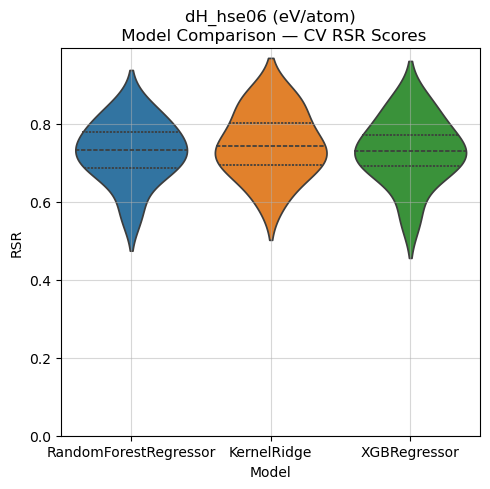

In [35]:
make_violin_plot_rsr(X, y1, models_1)

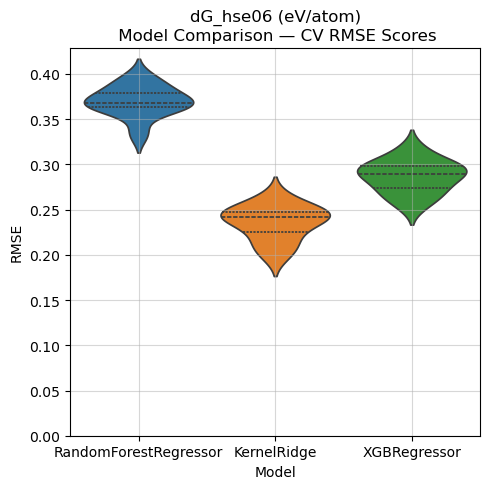

In [36]:
models_2 = [rf_2, kr_2, xgb_2]
make_violin_plot_rmse(X, y2, models_2)

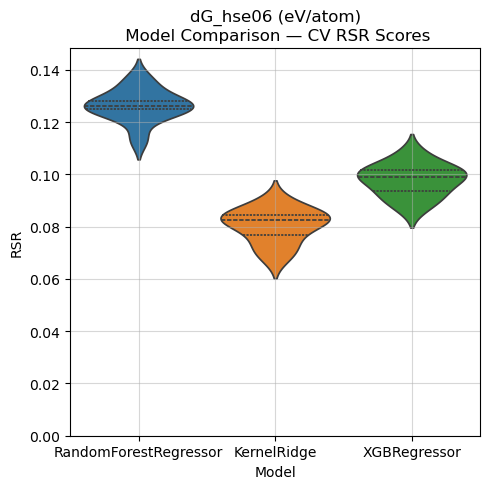

In [37]:
make_violin_plot_rsr(X, y2, models_2)